In [1]:
# Libs
import phobos
import numpy as np
import matplotlib.pyplot as plt
import time
import pickle
from tqdm import tqdm

✅ BMC lib found. Running in control mode.


In [2]:
# Constants
lam = 1550 # [nm]

In [3]:
# shortcuts
dm = phobos.DM()
cam = phobos.Cred3()
chip = phobos.Arch6()
inj_seg = phobos.Config().get('injection.segments')
print('Injected segments:', inj_seg)

beam = 0
seg = inj_seg[beam]
print('Segment:', seg)

# Setup
path = phobos.archive.new('single_beam', verbose=True)


DEBUG - SDK Install Path: /opt/Boston Micromachines
DEBUG - BMC_PCIeOpenDM 27BW007#051 0
DEBUG - 1 BMC PCIe cards installed.
DEBUG - Using automatic devId: 1
DEBUG - BMC_PCIeOpenDM opening 0
INFO - PCIe HW Rev: 20000502
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
INFO - Loading calibration for DM: 27BW07#051_5_3_setof14
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
Cred3 camera initialized with dark subtraction
Injected segments: [138, 137, 136, 135]
Segment: 138
Archive created at /mnt/disk1/archive/2026-03-27_a43da1f/1_single_beam


In [4]:
# # check cropping
# cam.check_cropping()

In [6]:
inj = phobos.Injection()
chip.turn_off()

factors = [[17.,          0.57604216,  0.09167996],
            [18.,          0.60317584,  0.09599842],
            [19.,          0.59872363,  0.09528982],
            [20.,          0.59818263,  0.09520372]]
factors = np.array(factors)

for idx, shifter in enumerate(chip.shifters):
    shifter.phase_factor = factors[idx, 2]

# Injection calibration

Scanning injection maps:   0%|          | 0/4 [00:00<?, ?it/s]

  Channel 0 (segment 138): scanning…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])


Scanning injection maps:  25%|██▌       | 1/4 [00:18<00:54, 18.18s/it]

Injection OFF on channels [0] (segments [138])
  Channel 1 (segment 137): scanning…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])


Scanning injection maps:  50%|█████     | 2/4 [00:40<00:41, 20.78s/it]

...

Scanning injection maps:  75%|███████▌  | 3/4 [00:58<00:19, 19.23s/it]

Injection OFF on channels [2] (segments [136])
  Channel 3 (segment 135): scanning…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])


Scanning injection maps: 100%|██████████| 4/4 [01:11<00:00, 17.85s/it]

Injection OFF on channels [3] (segments [135])
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])

── Find gross TT for max injection and spread ──
Injection spread of seg=138: (tip, tilt) = (0.73874,0.67494) mrad
Injection spread of seg=137: (tip, tilt) = (0.67933,0.74490) mrad
Injection spread of seg=136: (tip, tilt) = (0.67811,0.73050) mrad
Injection spread of seg=135: (tip, tilt) = (0.71169,0.74632) mrad

── Find precise TT for max injection ──
Injection max of seg=138: (tip, tilt) = (-0.52017,0.46943) mrad; flux = 984.5
Injection max of seg=137: (tip, tilt) = (-0.21062,0.37408) mrad; flux = 1124
Injection max of seg=136: (tip, tilt) = (0.15212,0.27495) mrad; flux = 951.4
Injection max of seg=135: (tip, tilt) = (0.33211,0.26586) mrad; flux = 1010
✅ Injection calibration saved to config (injection.max)



── Finding maximum injection points ──

── Balancing injection fluxes ──
  Weakest channel: 2 (seg 136), target flux = 957.3
  Dichotomy on channel 0 (seg 138)…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])
    → balanced tilt = 0.6541 mrad, flux = 958.9 (target 957.3), iterations = 13
  Dichotomy on channel 1 (seg 137)…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])
    → balanced tilt = 0.5827 mrad, flux = 961.2 (target 957.3), iterations = 13
  Dichotomy on channel 3 (seg 135)…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])
    → balanced tilt = 0.5563 mrad, flux = 957.8 (target 957.3), iterations = 13
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
✅ Injection calibration saved to config (injection.balanced)


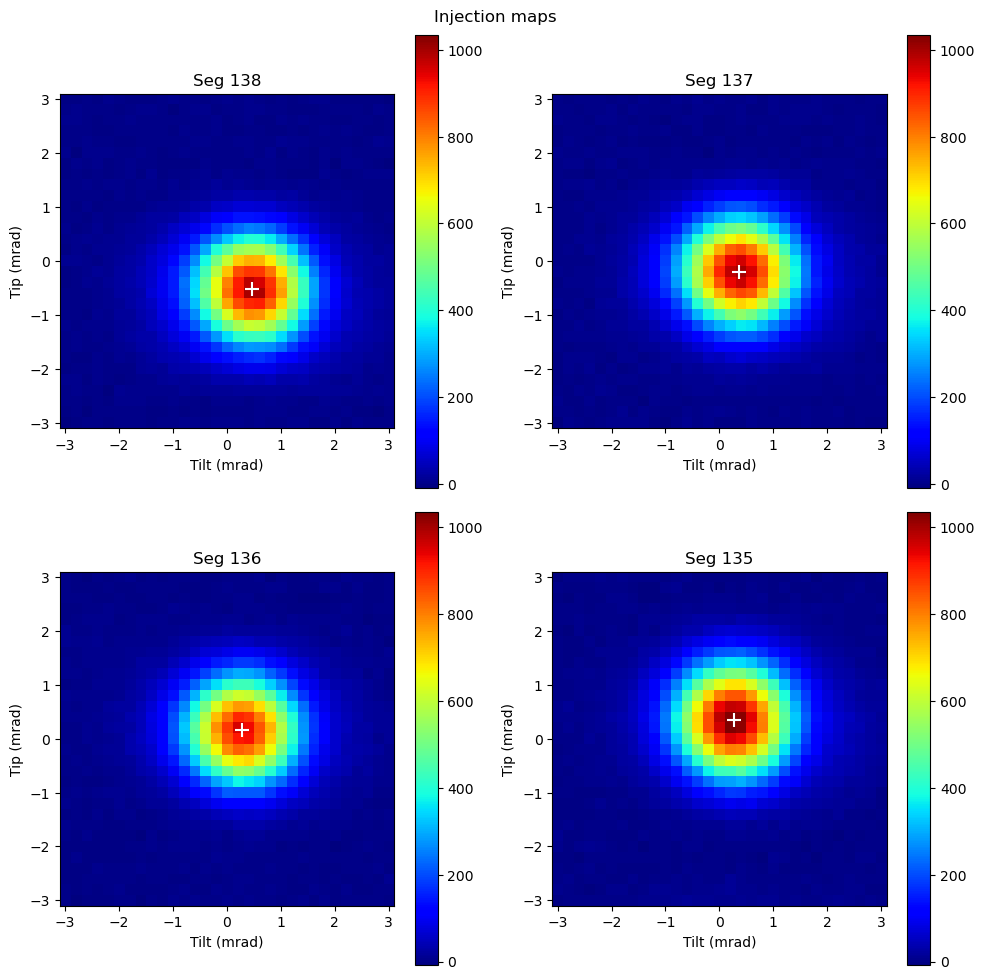

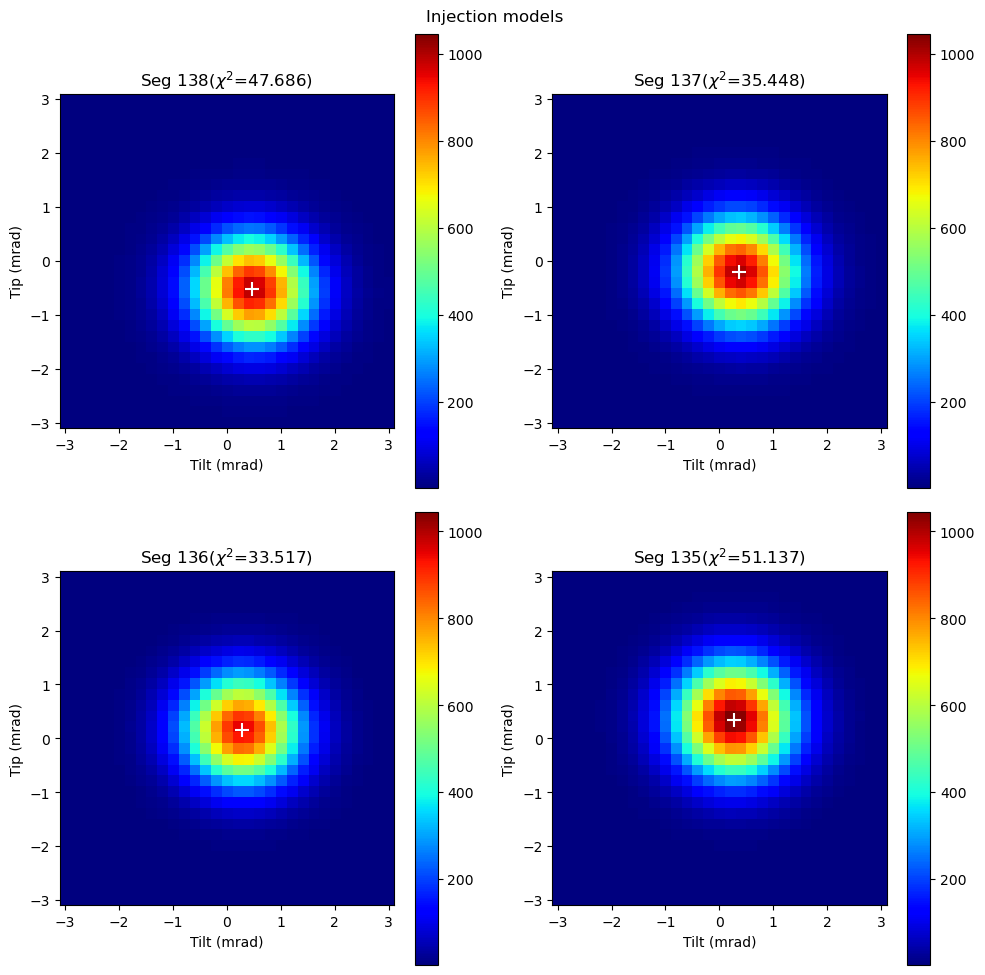

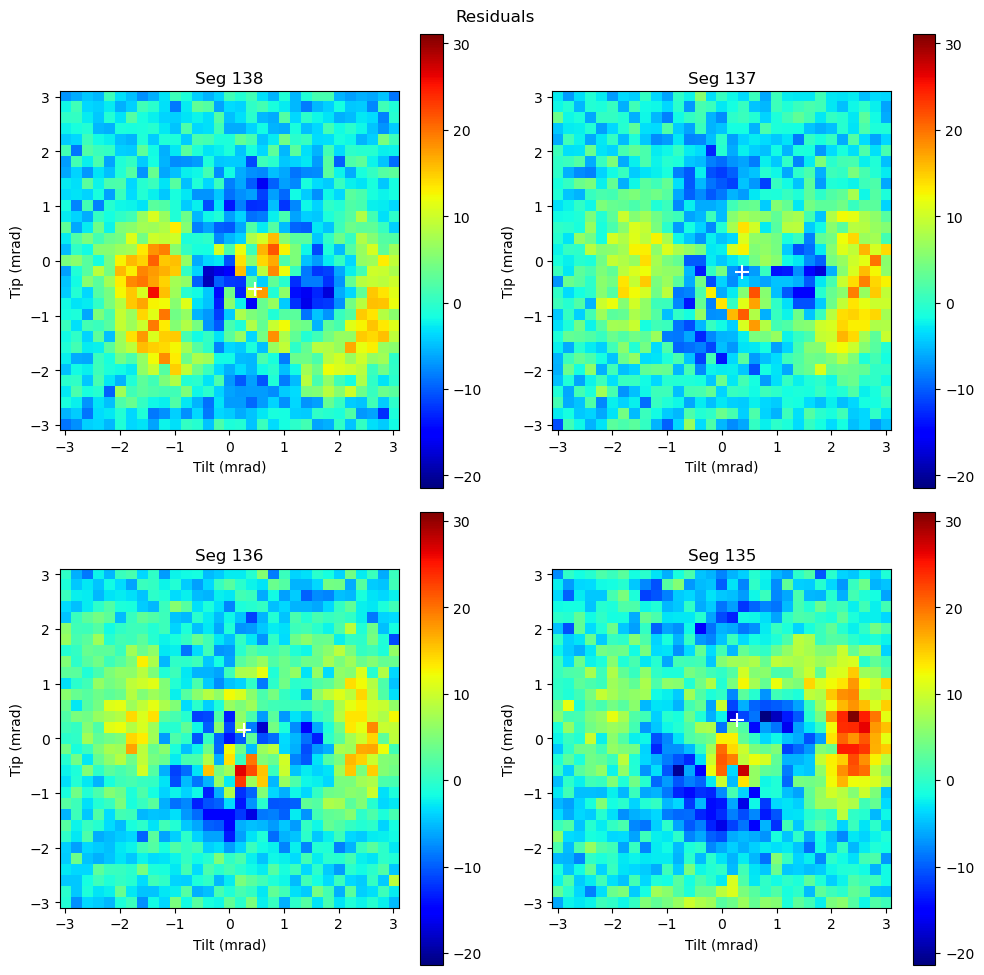

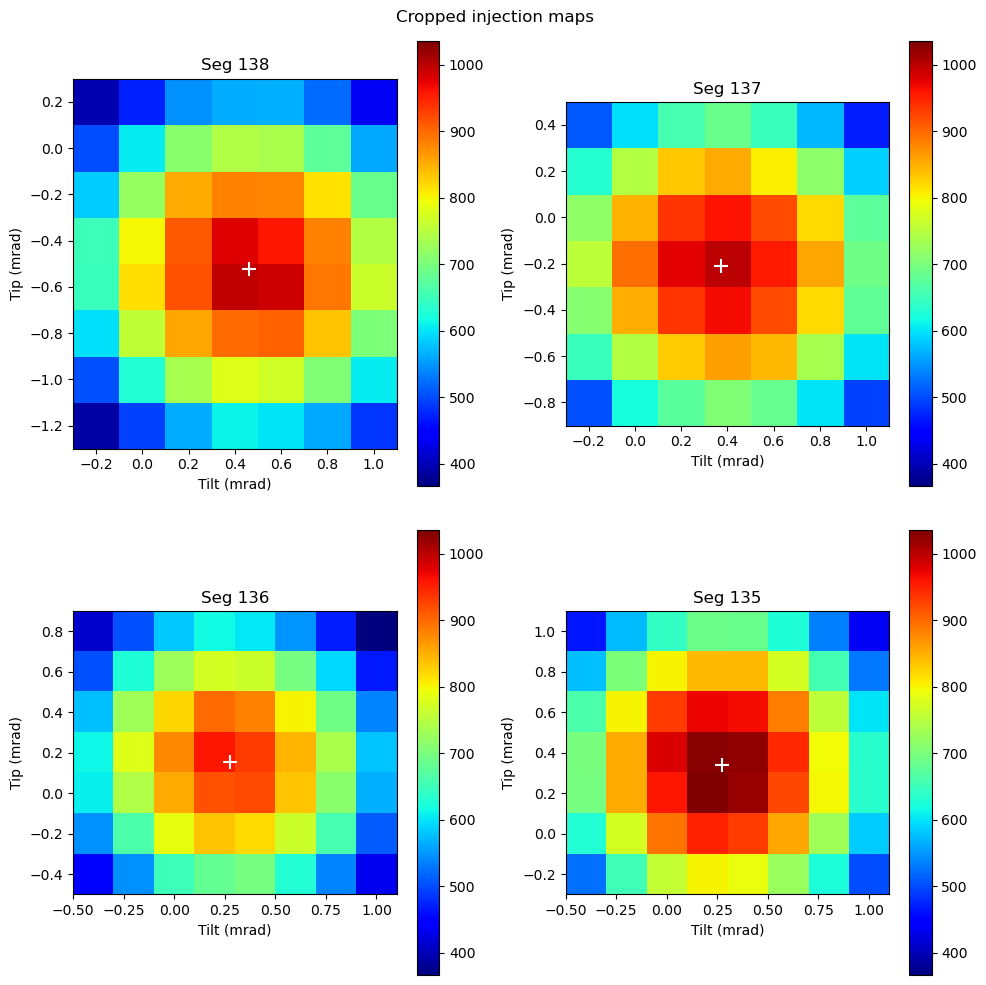

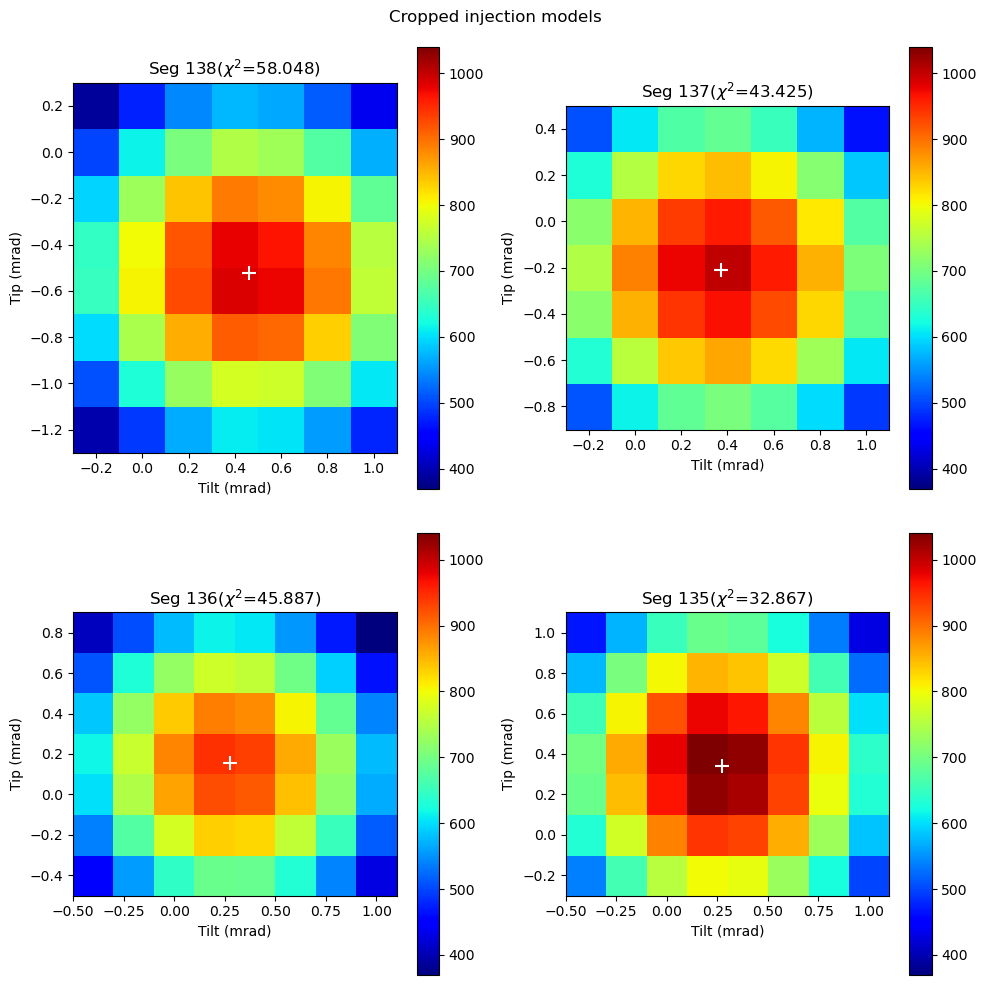

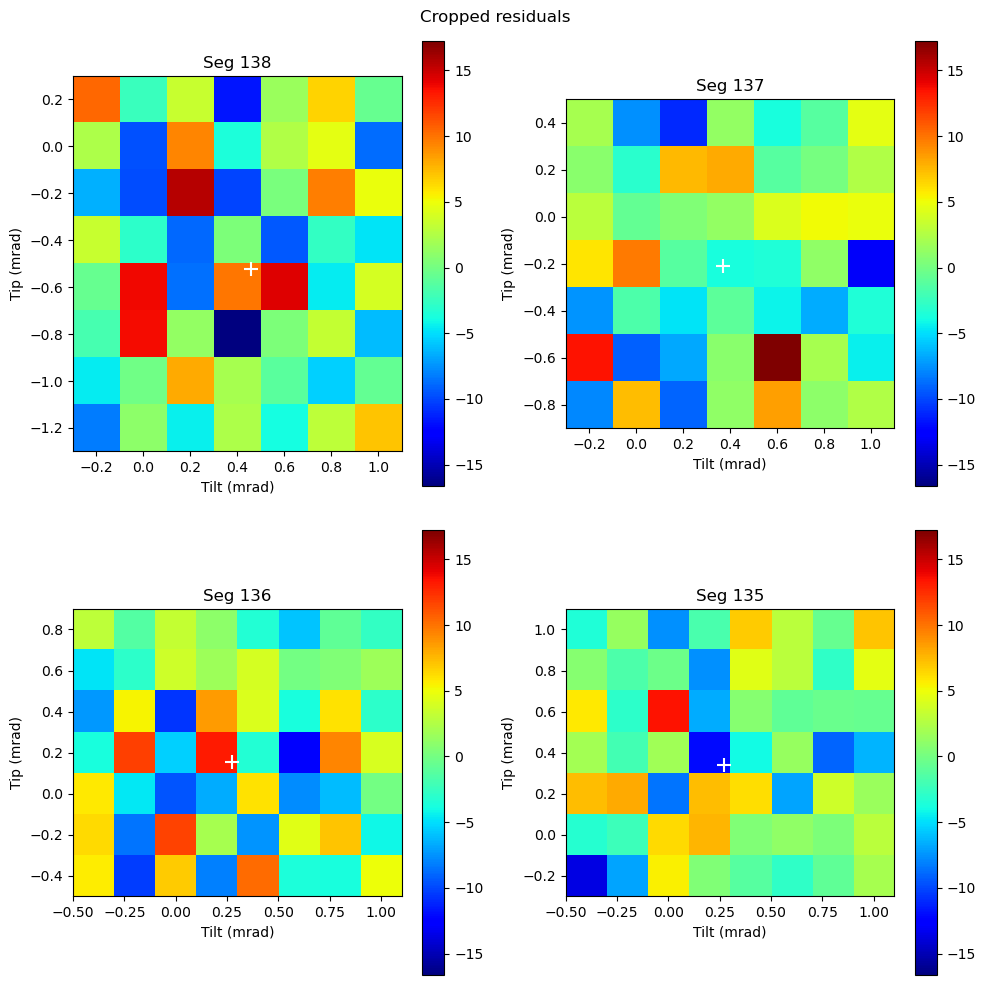

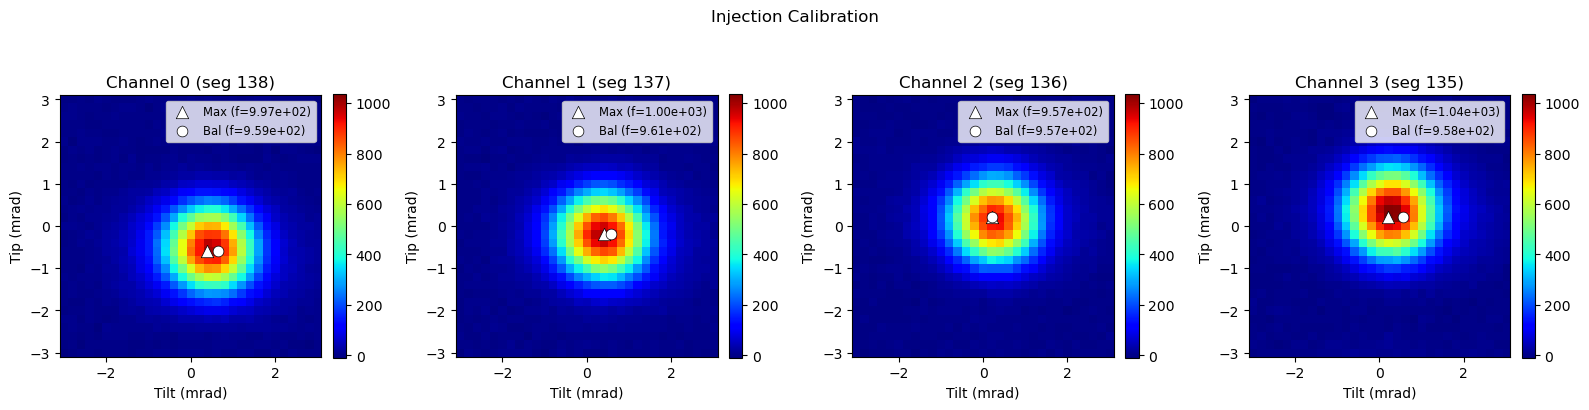

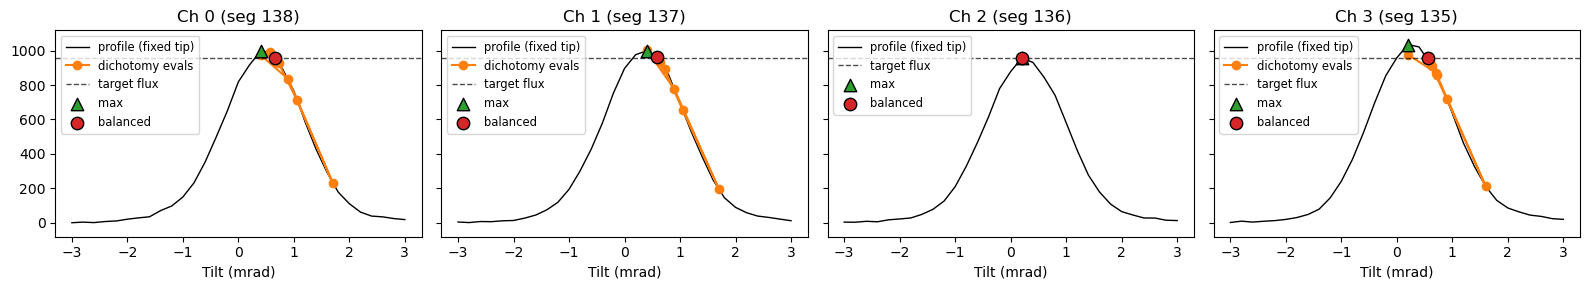

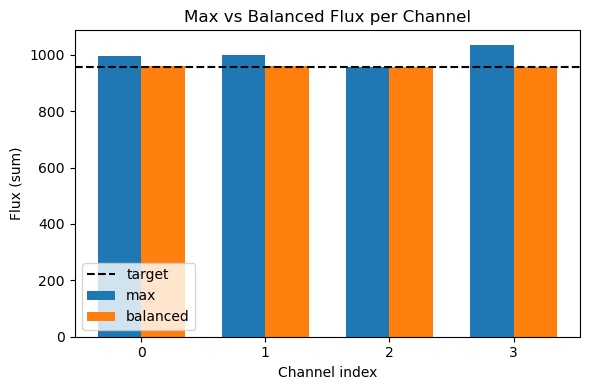

Successfully saved in FITS
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


In [7]:
# Injection calibration
avg_frame = 1
avg_frames_bal = 5
out_inj = inj.calibrate(verbose=True, plot=True, save_path=path, 
                        avg_frames=avg_frame, avg_frames_bal=avg_frames_bal,
                        tilt_tol=0.5e-3)

inj.zero()

# TOPA calibration

Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
🔧 Calibrating phase for 4 shifters...
  - Scanning shifter 17 1/5
Correcting drift...
  - Scanning shifter 17 2/5
Correcting drift...
  - Scanning shifter 17 3/5
Correcting drift...
  - Scanning shifter 17 4/5
Correcting drift...
  - Scanning shifter 17 5/5
Correcting drift...
Phase-to-power calibration...
  ✅ Shifter 17 calibrated: Period=0.5760 W -> Coeff=0.0917 W/rad
  - Scanning shifter 18 1/5
Correcting drift...
  - Scanning shifter 18 2/5
Correcting drift...
  - Scanning shifter 18 3/5
Correcting drift...
  - Scanning shifter 18 4/5
Correcting drift...
  - Scanning shifter 18 5/5
Correcting drift...
Phase-to-power calibration...
  ✅ Shifter 18 calibrated: Period=0.6032 W -> Coeff=0.0960 W/rad
  - Scanning shifter 19 1/5
Correcting drift...
  - Scanning shifter 19 2/5
Correcting drift...
  - Scanning shifter 19 3/5
Correcting drift...
  - Scanning shifter 19 4/5
Correcting drift...
  - Scanning shifter 19 

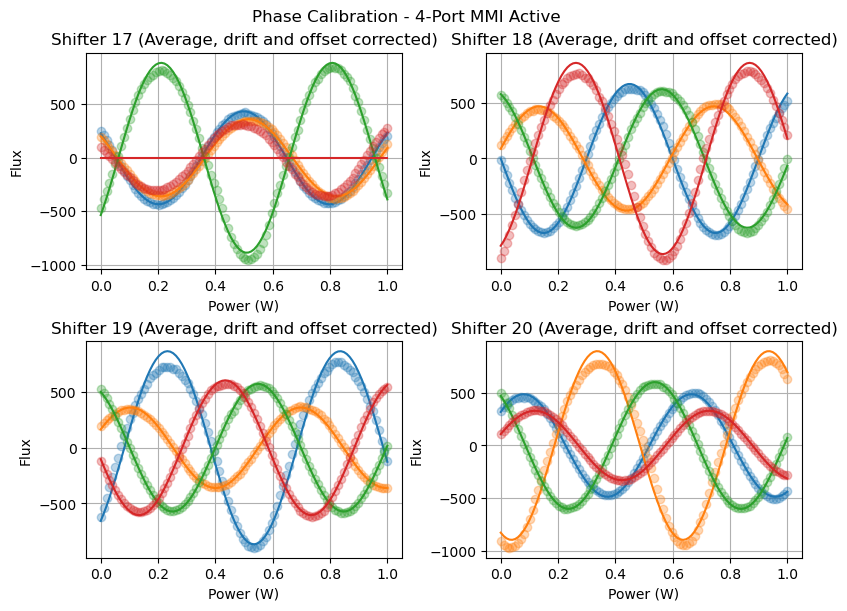

📊 Performing phase scan (0 to 2π) for verification...
  - Scanning phase for shifter 17...
  - Scanning phase for shifter 18...
  - Scanning phase for shifter 19...
  - Scanning phase for shifter 20...


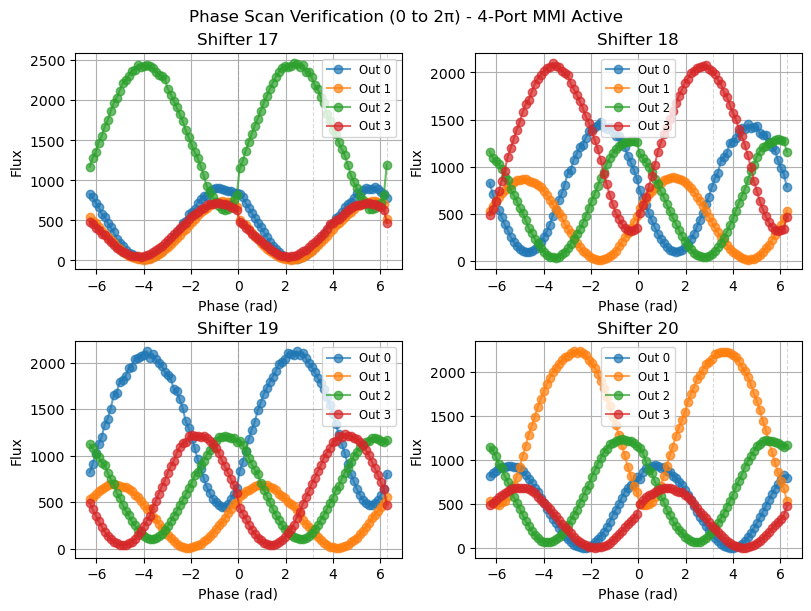

✅ Phase calibration completed.
Phase factor
[[17.          0.57604216  0.09167996]
 [18.          0.60317584  0.09599842]
 [19.          0.59872363  0.09528982]
 [20.          0.59818263  0.09520372]]


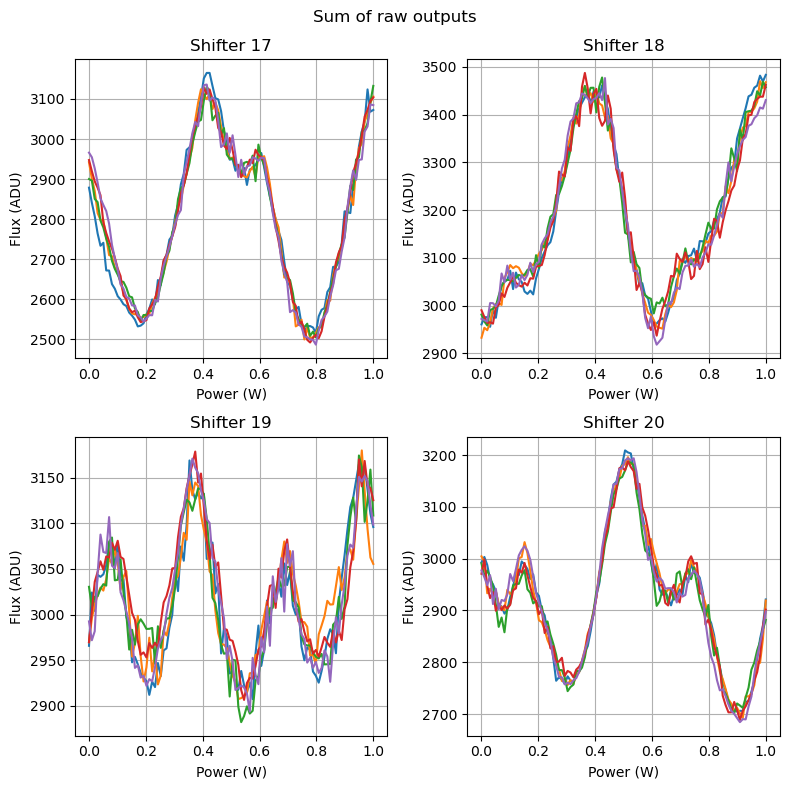

In [17]:
inj.set_balanced()

avg_frames = 5
# TOPAs calibration
chip_coeffs, chip_scans = chip.phase_calibration2(niter=5, plot=True, verbose=True, avg_frames=avg_frames)

np.save(path / f"chip_coeffs_seg{seg}.npy", chip_coeffs)
np.save(path / f"chip_scans_seg{seg}.npy", chip_scans)

print('Phase factor')
print(chip_coeffs)

s = chip_scans.sum(3)
power_range = np.linspace(0, 1, s.shape[-1])
plt.figure(figsize=(8,8))
plt.suptitle("Sum of raw outputs")
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(power_range, s[i].T)
    plt.grid()
    plt.title(f"Shifter {chip.shifters[i].channel}")
    plt.xlabel("Power (W)")
    plt.ylabel("Flux (ADU)")
plt.tight_layout()

chip.turn_off()

# Conservation of energy?

Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


100%|██████████| 100/100 [00:07<00:00, 12.90it/s]


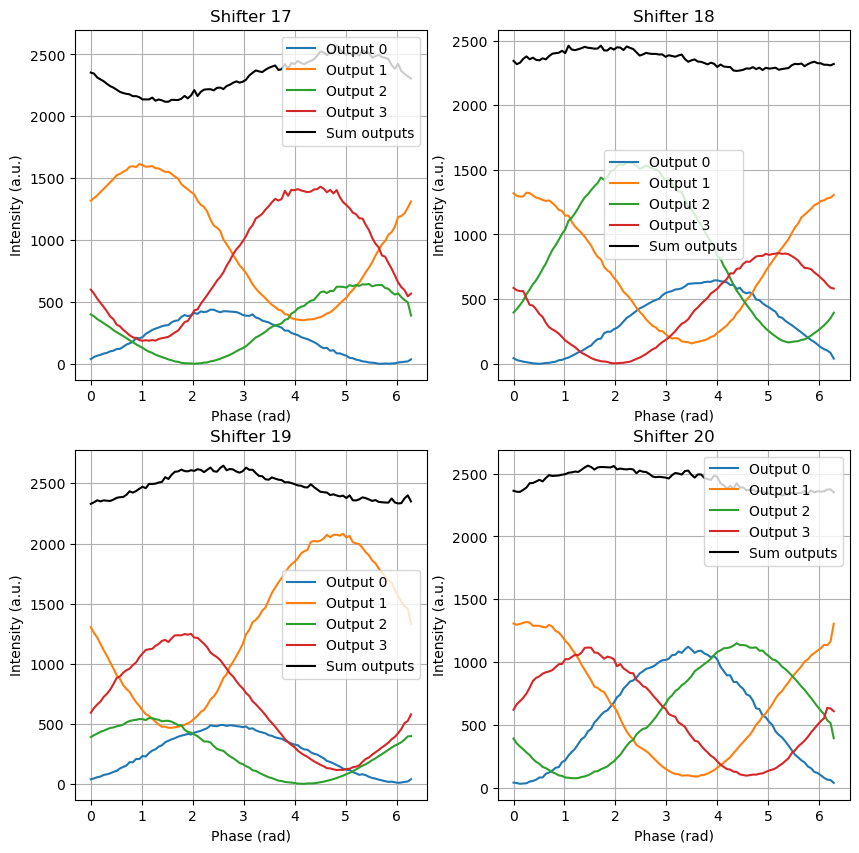

In [14]:
phase_ramp = np.linspace(0, 2 * np.pi, 100)
n_roi = 4
inj.set_balanced()

data_cube = []
for shifter in chip.shifters:
    imgs = []
    for p in tqdm(phase_ramp):
        _ = shifter.set_phase(p)
        img = cam.get_outputs(flux_mode='mean')[:n_roi]
        imgs.append(img)
    data_cube.append(imgs)

data_cube = np.array(data_cube) # Shape (n_shifters, n_phases, n_roi)

fig, axs = plt.subplots(2, 2, figsize=(10,10))
for i, ax in enumerate(axs.flat):
    ax.plot(phase_ramp, data_cube[i])
    ax.plot(phase_ramp, data_cube[i].sum(1), c='k')
    ax.grid(True)
    ax.legend([f'Output {j}' for j in range(n_roi)]+['Sum outputs'])
    ax.set_xlabel("Phase (rad)")
    ax.set_ylabel("Intensity (a.u.)")
    ax.set_title(f"Shifter {chip.shifters[i].channel}")

# Test : 2pi*0.99 shift (to reach max power delivered)

In [15]:
# Set a 2pi shift
n_roi = 4
wait = 0.01
data_cube = []
power_cube = []

chip.turn_off()
time.sleep(1)
for shifter in chip.shifters:
    data_shifters = []
    power_shifters = []
    flx = cam.get_outputs(flux_mode='mean')[:n_roi]
    data_shifters.append(flx)
    power_shifters.append([-0.1, -0.1])
    
    pw = shifter.set_phase(2 * np.pi * 0.99)
    time.sleep(wait)
    flx = cam.get_outputs(flux_mode='mean')[:n_roi]
    data_shifters.append(flx)
    power_shifters.append(pw)

    pw = shifter.set_phase(0.)
    time.sleep(wait)
    flx = cam.get_outputs(flux_mode='mean')[:n_roi]
    data_shifters.append(flx)
    power_shifters.append(pw)

    chip.turn_off()
    time.sleep(wait)
    flx = cam.get_outputs(flux_mode='mean')[:n_roi]
    data_shifters.append(flx)
    power_shifters.append([-0.1, -0.1])

    data_cube.append(data_shifters)
    power_cube.append(power_shifters)

data_cube = np.array(data_cube) # shape (n_shifters, n_frames, n_roi)
power_cube = np.array(power_cube) # shape (n_shifters, n_frames, n_pw)

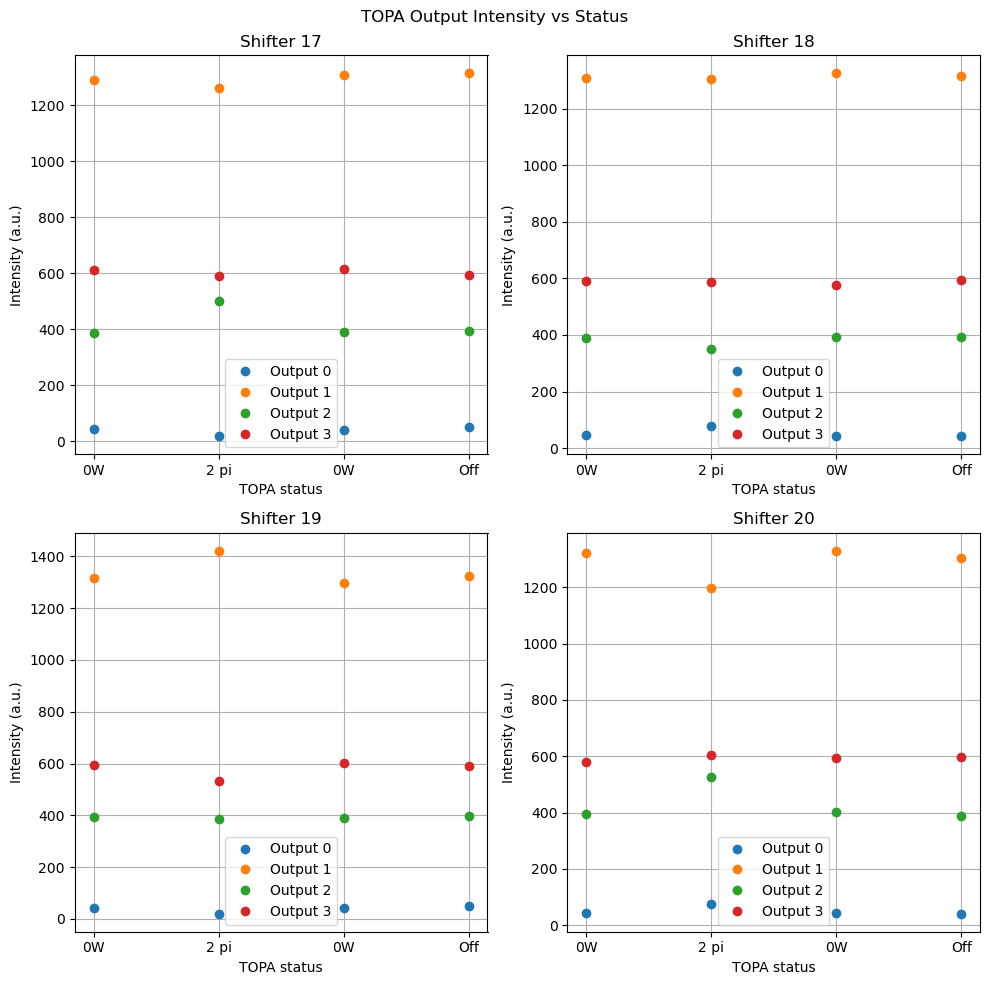

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle("TOPA Output Intensity vs Status")
for i, ax in enumerate(axs.flat):
    ax.plot(data_cube[i], 'o')
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['0W', '2 pi', '0W', 'Off'])
    ax.grid(True)
    ax.legend([f'Output {j}' for j in range(n_roi)])
    ax.set_ylabel("Intensity (a.u.)")
    ax.set_xlabel("TOPA status")
    ax.set_title(f"Shifter {chip.shifters[i].channel}")
fig.tight_layout()

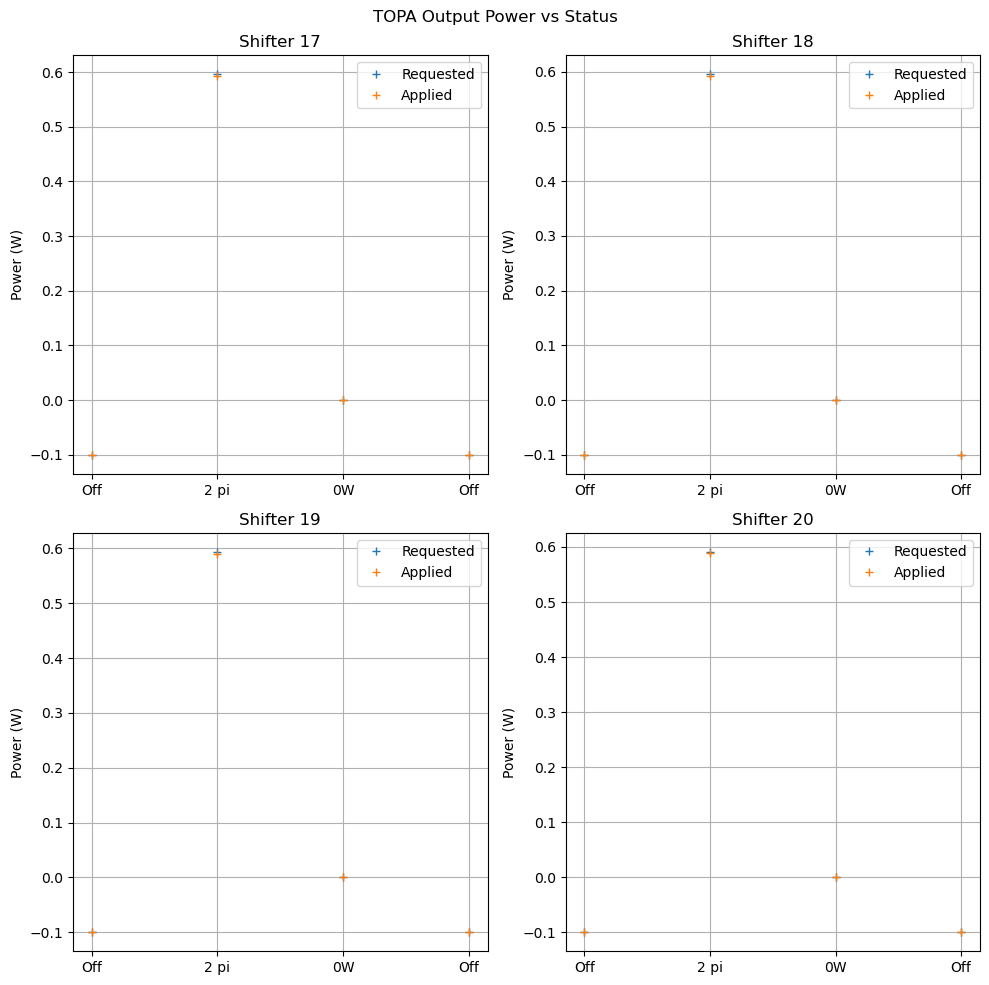

In [17]:
fig, axs = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle("TOPA Output Power vs Status")
for i, ax in enumerate(axs.flat):
    ax.plot(power_cube[i], '+')
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['Off', '2 pi', '0W', 'Off'])    
    ax.grid(True)
    ax.legend(['Requested', 'Applied'])
    ax.set_ylabel("Power (W)")
    ax.set_title(f"Shifter {chip.shifters[i].channel}")
fig.tight_layout()

# Test : diff power sent
Can't see any relaxation time of the heat despite putting stabilization_time at 0 in bench.yml and no sleep time in the cell below.

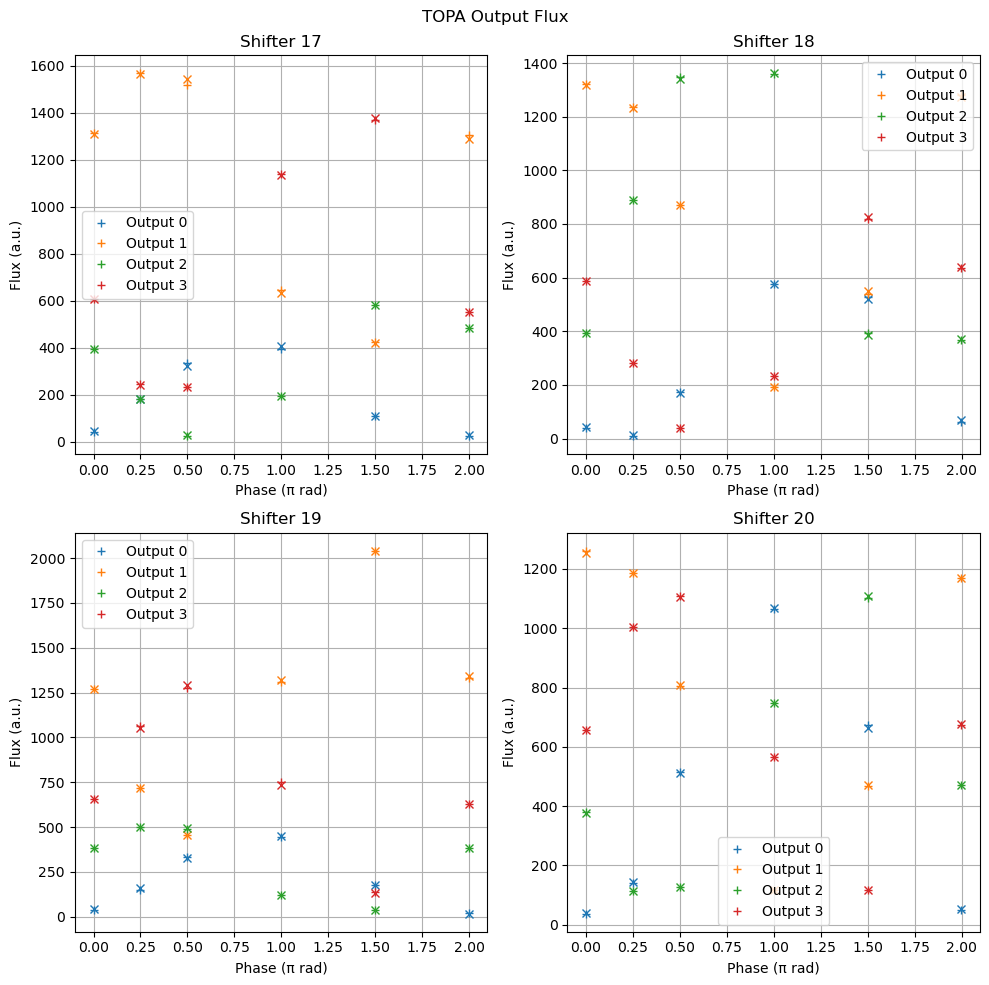

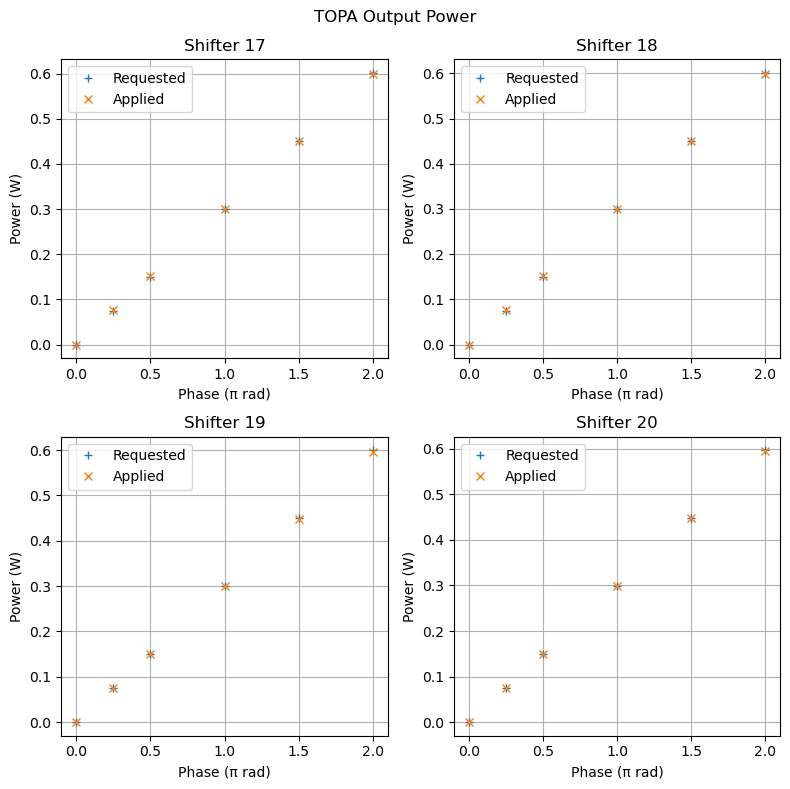

In [18]:
phobos.Config().reload()
phase_change = np.array([0., np.pi / 4, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi*0.999])
wait = 0.
n_output = 4
chip.turn_off()

data = []
data_relax = []
telemetry = []

for shifter in chip.shifters:
    outs = []
    outs_relax = []
    outs_power = []
    for ph in phase_change:
        pw = shifter.set_phase(ph)
        flx = cam.get_outputs(flux_mode='mean')[:n_output]
        outs.append(flx)
        outs_power.append(pw)
        time.sleep(wait)
        flx_relax = cam.get_outputs(flux_mode='mean')[:n_output]
        outs_relax.append(flx_relax)
        shifter.turn_off()
        time.sleep(wait)
    data.append(outs)
    data_relax.append(outs_relax)
    telemetry.append(outs_power)

data = np.array(data) # shape (n_shifters, n_phases, n_output)
data_relax = np.array(data_relax) # shape (n_shifters, n_phases, n_output)
telemetry = np.array(telemetry) # shape (n_shifters, n_phases, 2)

fig, axs = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle("TOPA Output Flux")
for i, ax in enumerate(axs.flat):
    for k in range(data.shape[-1]):
        line, = ax.plot(phase_change/np.pi, data[i,:,k], '+', label=f'Output {k}')
        ax.plot(phase_change/np.pi, data_relax[i,:,k], 'x', c=line.get_color())
    ax.grid(True)
    ax.legend(ncols=1)
    ax.set_ylabel("Flux (a.u.)")
    ax.set_xlabel("Phase (π rad)")
    ax.set_title(f"Shifter {chip.shifters[i].channel}")
fig.tight_layout()

fig, axs = plt.subplots(2, 2, figsize=(8,8))
fig.suptitle("TOPA Output Power")
for i, ax in enumerate(axs.flat):
    ax.plot(phase_change/np.pi, telemetry[i,:,0], '+', label=f'Requested')
    ax.plot(phase_change/np.pi, telemetry[i,:,1], 'x', label=f'Applied')
    ax.grid(True)
    ax.legend()
    ax.set_ylabel("Power (W)")
    ax.set_xlabel("Phase (π rad)")
    ax.set_title(f"Shifter {chip.shifters[i].channel}")
fig.tight_layout()

# Single beam and phase shifter crosstalk

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0] (segments [138])
Scanning shifter: 17


100%|██████████| 101/101 [00:08<00:00, 12.44it/s]


Scanning shifter: 18


100%|██████████| 101/101 [00:08<00:00, 12.51it/s]


Scanning shifter: 19


...

Scanning shifter: 19


100%|██████████| 101/101 [00:08<00:00, 12.51it/s]


Scanning shifter: 20


100%|██████████| 101/101 [00:08<00:00, 12.51it/s]


(4, 4, 101, 4)
Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


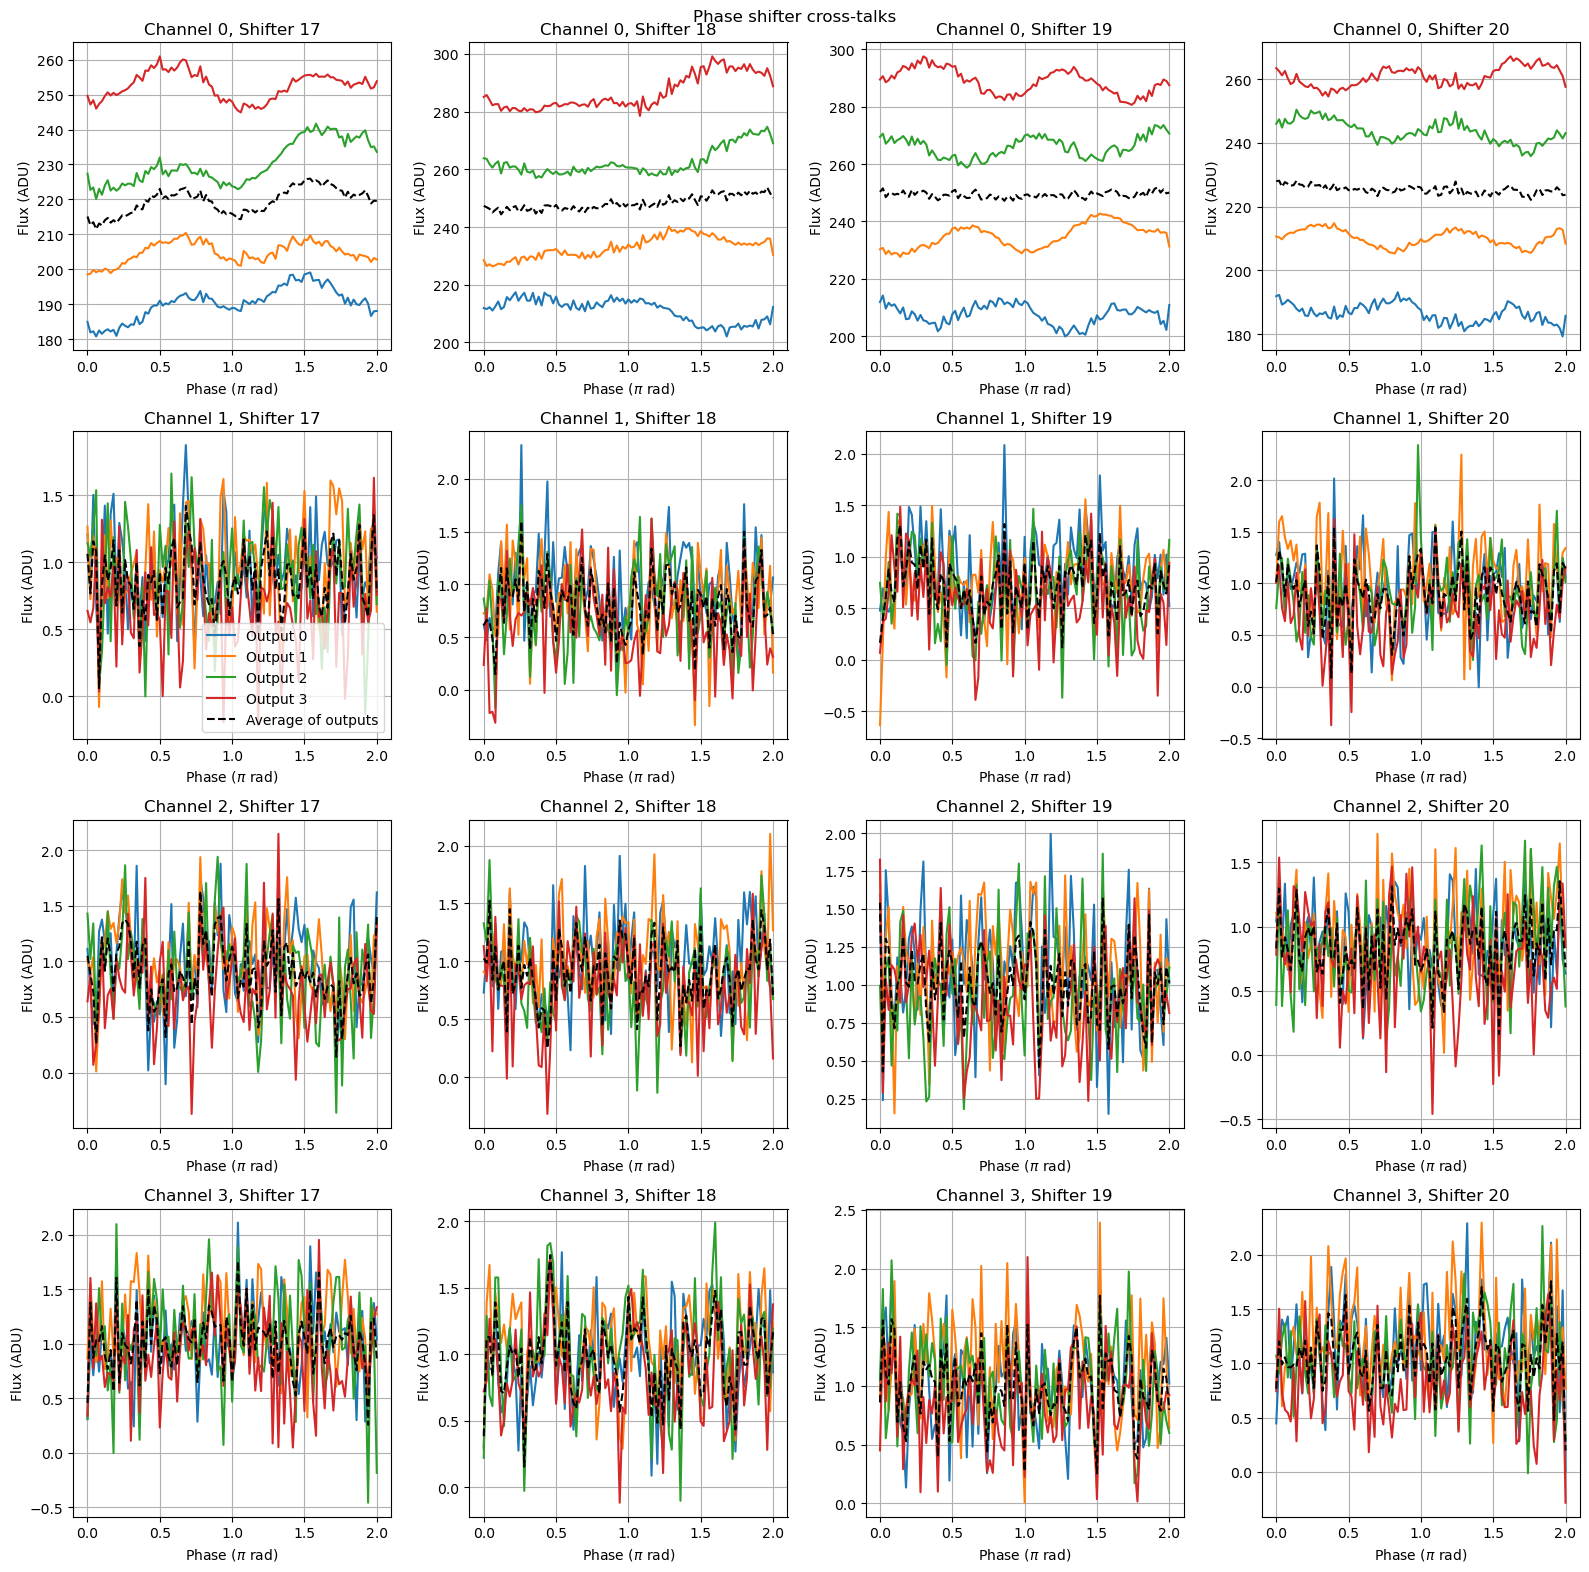

In [8]:
channels = [0, 1, 2, 3]
phase_ramp = np.linspace(0, 2*np.pi, 101)
n_outputs = 4
avg_frames = 5
niter = 5
chip.turn_off()

data = []
for ch in channels:
    inj.off()
    inj.set_balanced(ch)
    flx_shifter = []
    for shifter in chip.shifters:
        print('Scanning shifter:', shifter.channel)
        iter_list = []
        for it in range(niter):
            flux = []
            for phase in tqdm(phase_ramp):
                shifter.set_phase(phase)
                flx = cam.get_outputs(flux_mode='mean', stack=avg_frames)[:n_outputs]
                flux.append(flx)
            iter_list.append(flux)
        iter_list = np.array(iter_list)
        iter_list = iter_list.mean(0)
        flx_shifter.append(iter_list)
        shifter.turn_off()
        time.sleep(1.)
    data.append(flx_shifter)

data = np.array(data) # shape (n_channels, n_shifters, n_phases, n_outputs)
print(data.shape)
np.savez(path / f'phase_shifter_seg{seg}_crosstalks', data=data, phase_ramp=phase_ramp)

inj.set_balanced()
chip.turn_off()

fig, axs = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Phase shifter cross-talks')
for ch in channels:
    for shifter_idx, shifter in enumerate(chip.shifters):
        axs[ch, shifter_idx].plot(phase_ramp/np.pi, data[ch, shifter_idx])
        axs[ch, shifter_idx].plot(phase_ramp/np.pi, data[ch, shifter_idx].mean(-1), '--', c='k')
        axs[ch, shifter_idx].set_title(f'Channel {ch}, Shifter {shifter.channel}')
        axs[ch, shifter_idx].set_xlabel(r'Phase ($\pi$ rad)')
        axs[ch, shifter_idx].set_ylabel('Flux (ADU)')
        axs[ch, shifter_idx].grid(True)
        if ch == 1 and shifter_idx == 0:
            axs[ch, shifter_idx].legend([f'Output {i}' for i in range(n_outputs)]+['Average of outputs'], loc='best')
fig.tight_layout()
fig.savefig(path / f'phase_shifter_seg{seg}_crosstalks.png', dpi=150)



# Incoherent scan

Segment: 138
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection MAX on channels [0] (segments [138])
Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


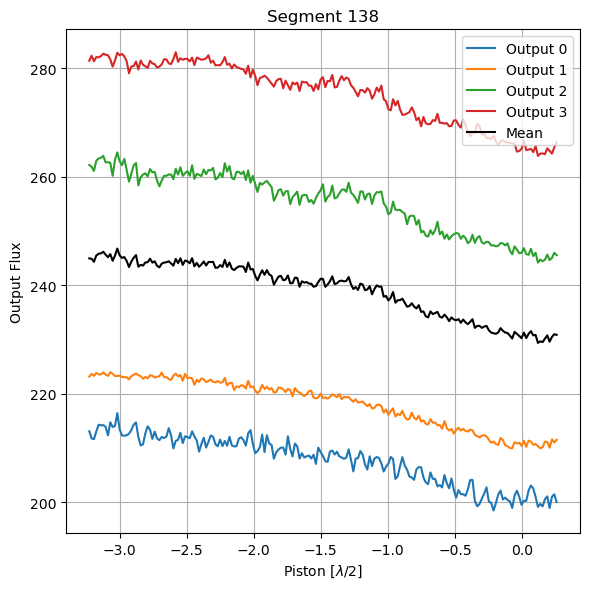

In [9]:
n_roi = 4
avg_frames = 5
piston_range = np.linspace(-2500, 200, 201)  # [nm]
print('Segment:', seg)
niter = 5

res_single_scan = {}
fig, axs = plt.subplots(1, 1, figsize=(6, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

total_flux = []
chip.turn_off()
inj.off()
inj.set_max(beam)

ref_tip = dm[inj_seg[beam]].get_tip()
ref_tilt = dm[inj_seg[beam]].get_tilt()

outs = np.empty((niter, len(piston_range), n_roi))
for i in range(niter):
    outs_iter = np.empty((len(piston_range), n_roi))
    for p, opd in enumerate(piston_range):
        dm[inj_seg[beam]].set_ptt(opd, ref_tip, ref_tilt)
        time.sleep(0.005)
        outs_iter[p] = cam.get_outputs(flux_mode='mean', stack=avg_frames)[:n_roi]
    outs[i] = outs_iter
outs = outs.mean(0)

res_single_scan[inj_seg[beam]] = outs.copy()
total_flux.append(outs[:].sum(axis=1))

for o in range(n_roi):
    axs.plot(piston_range / (lam/2), outs[:, o], color=colors[o], linestyle='-', label=f'Output {o}')
axs.plot(piston_range / (lam/2), outs.mean(1), color='k', linestyle='-', label=f'Mean')
axs.set_title(f'Segment {inj_seg[beam]}')
axs.set_xlabel(r'Piston [$\lambda/2$]')
axs.set_ylabel('Output Flux')
axs.legend()
axs.grid()


fig.tight_layout()
fig.savefig(path / f'singlebeam_seg{seg}_scan_incoherent.png')

np.savez(path / f'singlebeam_seg{seg}_scan_incoherent.npz', data=outs, piston_range=piston_range)

inj.set_balanced()


# The end

In [10]:
print('Path is', path)

inj.zero()
phobos.XPOW().turn_off()

Path is /mnt/disk1/archive/2026-03-27_a43da1f/1_single_beam
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
